In [1]:
import numpy as np
from scipy import stats
from scipy.interpolate import griddata

import einops
import concurrent.futures
import pickle

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import niapy
from niapy.problems import Alpine1 as TestFunction

import hiposa
import hiposa.poisson_tiler
from hiposa.poisson_disc_sampling import PoissonDiskSamplerWithExisting
from hiposa.point_selector import PointSelector

from scipy.interpolate import CloughTocher2DInterpolator
from scipy.spatial import Delaunay


import os

import scipy.ndimage as ndi

from sklearn.model_selection import KFold

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

def bivariate_normal(xy, mu_x=0, mu_y=0, sigma_x=1, sigma_y=1, rho=0):
    """
    Calculate the bivariate normal distribution at points (x, y).
    
    Parameters:
    -----------
    x, y : array-like
        The coordinates at which to evaluate the function
    mu_x, mu_y : float
        The means of the distribution in x and y directions
    sigma_x, sigma_y : float
        The standard deviations in x and y directions
    rho : float
        The correlation coefficient between x and y (-1 ≤ rho ≤ 1)
        
    Returns:
    --------
    array-like
        The probability density at each point (x, y)
    """
    x = xy[0]
    y = xy[1]
    
    # Normalize variables
    x_norm = (x - mu_x) / sigma_x
    y_norm = (y - mu_y) / sigma_y
    
    # Calculate exponential term
    z = x_norm**2 - 2*rho*x_norm*y_norm + y_norm**2
    exponent = -z / (2 * (1 - rho**2))
        
    return np.exp(exponent)

def sigmoid(x, threshold=0, slope=1):
    """
    Apply a sigmoid transformation to the input values.
    
    Parameters:
    -----------
    x : array-like
        Input values
    threshold : float
        The midpoint of the sigmoid (where sigmoid=0.5)
    slope : float
        Controls the steepness of the sigmoid transition
        
    Returns:
    --------
    array-like
        Transformed values between 0 and 1
    """
    return 1 / (1 + np.exp(-slope * (x - threshold)))

class DoublePeakDistribution:
    """
    A class representing a double-peaked distribution created from two bivariate normal 
    distributions, with optional sigmoid transformation.
    """
    
    def __init__(self, 
                mu_x1=-1, mu_y1=1, sigma_x1=1, sigma_y1=1, rho1=0.75,  # First peak parameters
                mu_x2=1, mu_y2=-1, sigma_x2=1, sigma_y2=1, rho2=0.50,   # Second peak parameters
                weight1=0.5,                                        # Weight of first peak (0-1)
                threshold=0.15, slope=50.4,                         # Sigmoid parameters
                normalize=True):                                    # Whether to normalize the sum
        """
        Initialize the double-peaked distribution parameters.
        
        Parameters:
        -----------
        mu_x1, mu_y1 : float
            The means of the first distribution
        sigma_x1, sigma_y1 : float
            The standard deviations of the first distribution
        rho1 : float
            The correlation coefficient of the first distribution
        mu_x2, mu_y2 : float
            The means of the second distribution
        sigma_x2, sigma_y2 : float
            The standard deviations of the second distribution
        rho2 : float
            The correlation coefficient of the second distribution
        weight1 : float
            The weight of the first distribution (0-1)
        threshold : float
            The threshold value for the sigmoid function
        slope : float
            The slope parameter for the sigmoid function
        normalize : bool
            Whether to normalize the sum of the two distributions
        """
        self.mu_x1 = mu_x1
        self.mu_y1 = mu_y1
        self.sigma_x1 = sigma_x1
        self.sigma_y1 = sigma_y1
        self.rho1 = rho1
        
        self.mu_x2 = mu_x2
        self.mu_y2 = mu_y2
        self.sigma_x2 = sigma_x2
        self.sigma_y2 = sigma_y2
        self.rho2 = rho2
        
        self.weight1 = weight1
        self.weight2 = 1 - weight1
        
        self.threshold = threshold
        self.slope = slope
        self.normalize = normalize
        
        # Validate parameters
        if abs(rho1) >= 1 or abs(rho2) >= 1:
            raise ValueError("Correlation coefficients must be between -1 and 1")
        if sigma_x1 <= 0 or sigma_y1 <= 0 or sigma_x2 <= 0 or sigma_y2 <= 0:
            raise ValueError("Standard deviations must be positive")
        if not 0 <= weight1 <= 1:
            raise ValueError("Weight must be between 0 and 1")
    
    def __call__(self, xy, apply_sigmoid=False):
        """
        Evaluate the distribution at points (x, y).
        
        Parameters:
        -----------
        xy : tuple or array-like
            The (x, y) coordinates at which to evaluate the function
        apply_sigmoid : bool
            Whether to apply the sigmoid transformation
            
        Returns:
        --------
        array-like
            The (transformed) probability density at each point (x, y)
        """
        
        # Calculate both normal distributions
        normal1 = bivariate_normal(xy, self.mu_x1, self.mu_y1, self.sigma_x1, self.sigma_y1, self.rho1)
        normal2 = bivariate_normal(xy, self.mu_x2, self.mu_y2, self.sigma_x2, self.sigma_y2, self.rho2)

        # Combine with weights
        combined = self.weight1 * normal1 + self.weight2 * normal2

        # Normalize if requested (this helps ensure the sigmoid behaves consistently)
        # Apply sigmoid if requested
        if apply_sigmoid:
            return sigmoid(combined, self.threshold, self.slope)
        else:
            return combined

    def update_params(self, **kwargs):
        """
        Update the distribution parameters.
        
        Parameters:
        -----------
        **kwargs : dict
            The parameters to update
        """
        valid_params = ['mu_x1', 'mu_y1', 'sigma_x1', 'sigma_y1', 'rho1',
                       'mu_x2', 'mu_y2', 'sigma_x2', 'sigma_y2', 'rho2',
                       'weight1', 'threshold', 'slope', 'normalize']
        
        for param, value in kwargs.items():
            if param in valid_params:
                setattr(self, param, value)
            else:
                raise ValueError(f"Invalid parameter: {param}")
        
        # Update weight2 when weight1 changes
        if 'weight1' in kwargs:
            self.weight2 = 1 - self.weight1
            
        # Validate parameters after update
        if abs(self.rho1) >= 1 or abs(self.rho2) >= 1:
            raise ValueError("Correlation coefficients must be between -1 and 1")
        if self.sigma_x1 <= 0 or self.sigma_y1 <= 0 or self.sigma_x2 <= 0 or self.sigma_y2 <= 0:
            raise ValueError("Standard deviations must be positive")
        if not 0 <= self.weight1 <= 1:
            raise ValueError("Weight must be between 0 and 1")

    def plot(self, x_range=(-5, 5), y_range=(-5, 5), resolution=100, plot_type='both'):
        """
        Plot the double-peaked distribution with and without sigmoid transformation.
        
        Parameters:
        -----------
        x_range, y_range : tuple
            The range of x and y coordinates to plot
        resolution : int
            The number of points in each dimension
        plot_type : str
            'normal', 'sigmoid', or 'both'
        """
        # Create a grid of points
        x = np.linspace(x_range[0], x_range[1], resolution)
        y = np.linspace(y_range[0], y_range[1], resolution)
        X, Y = np.meshgrid(x, y)
        XY = (X, Y)
        
        # Calculate distributions
        Z_normal = self(XY, apply_sigmoid=False)
        Z_sigmoid = self(XY, apply_sigmoid=True)
        
        # Plotting
        if plot_type in ['normal', 'both']:
            fig1 = plt.figure(figsize=(10, 8))
            ax1 = fig1.add_subplot(111, projection='3d')
            surf1 = ax1.plot_surface(X, Y, Z_normal, cmap=cm.viridis, linewidth=0, antialiased=True)
            ax1.set_xlabel('X')
            ax1.set_ylabel('Y')
            ax1.set_zlabel('Probability Density')
            ax1.set_title('Double-Peaked Distribution')
            fig1.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)
        
        if plot_type in ['sigmoid', 'both']:
            fig2 = plt.figure(figsize=(10, 8))
            ax2 = fig2.add_subplot(111, projection='3d')
            surf2 = ax2.plot_surface(X, Y, Z_sigmoid, cmap=cm.plasma, linewidth=0, antialiased=True)
            ax2.set_xlabel('X')
            ax2.set_ylabel('Y')
            ax2.set_zlabel('Transformed Value')
            ax2.set_title(f'Sigmoid-Transformed Double-Peaked Distribution')
            fig2.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)
        
        plt.show()



In [35]:
lower= -5
upper= 5
#f = TestFunction(dimension=2, upper=upper, lower=lower, alpha=1/8.0)
f = DoublePeakDistribution(weight1=0.65)
#f.plot()
Ngrid = 500j
grid_x, grid_y = np.mgrid[lower:upper:Ngrid,lower:upper:Ngrid,]
f_gt = np.zeros_like(grid_x)
print("----------")
for i in range(500):
    for j in range(500):
        f_gt[i,j]=f( np.array( (grid_x[i,j], grid_y[i,j])).flatten())
        


----------


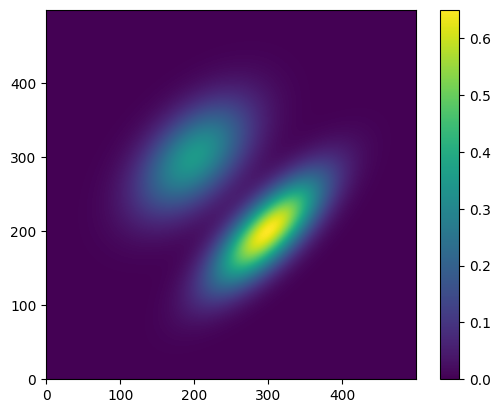

In [36]:
plt.imshow(f_gt, origin="lower")
plt.colorbar()
plt.show()

In [13]:
scales = (upper-lower)/5 / (np.sqrt(2)**np.arange(0,10,1))
pTiler = hiposa.poisson_tiler.PoissonTiler(tile_size=scales[0]*2, spacings=scales)
xy, levels = pTiler.get_points_in_region([[lower, upper], [lower, upper]])
total_points = len(xy) 
print(f"Total points generated: {total_points}")


Initializing PoissonTiler:
Requested tile size: 4.0
Actual tile size: 4.0 (minimum required: 4.0)
Spacings: [2.         1.41421356 1.         0.70710678 0.5        0.35355339
 0.25       0.1767767  0.125      0.08838835]
Dimensions: 2
Tile domain: [(0, 4.0), (0, 4.0)]

Generating base tile...

Generating level 0 with spacing 2.0
Level 0: Generated 1 points

Generating level 1 with spacing 1.414213562373095
Level 1: Generated 3 points

Generating level 2 with spacing 0.9999999999999998
Level 2: Generated 7 points

Generating level 3 with spacing 0.7071067811865474
Level 3: Generated 6 points

Generating level 4 with spacing 0.4999999999999999
Level 4: Generated 26 points

Generating level 5 with spacing 0.3535533905932736
Level 5: Generated 39 points

Generating level 6 with spacing 0.2499999999999999
Level 6: Generated 82 points

Generating level 7 with spacing 0.17677669529663678
Level 7: Generated 168 points

Generating level 8 with spacing 0.12499999999999994
Level 8: Generated 315

5
Level 4:
  Percentiles: work_obs=0.168, work=0.304, cal+delta=0.228
  Threshold: 0.228
  New points: 5


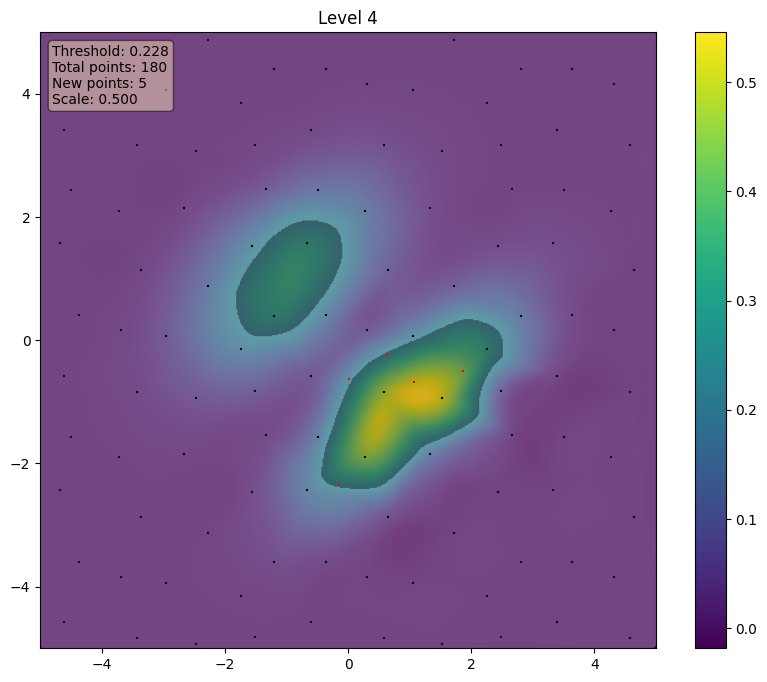

9
Level 5:
  Percentiles: work_obs=0.179, work=0.215, cal+delta=0.272
  Threshold: 0.215
  New points: 9


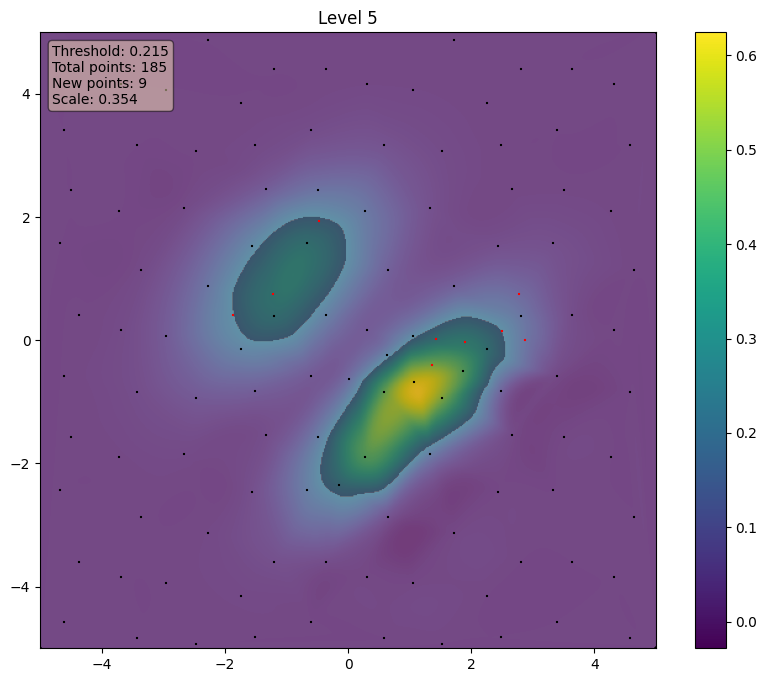

56
Level 6:
  Percentiles: work_obs=0.387, work=0.335, cal+delta=0.124
  Threshold: 0.124
  New points: 56


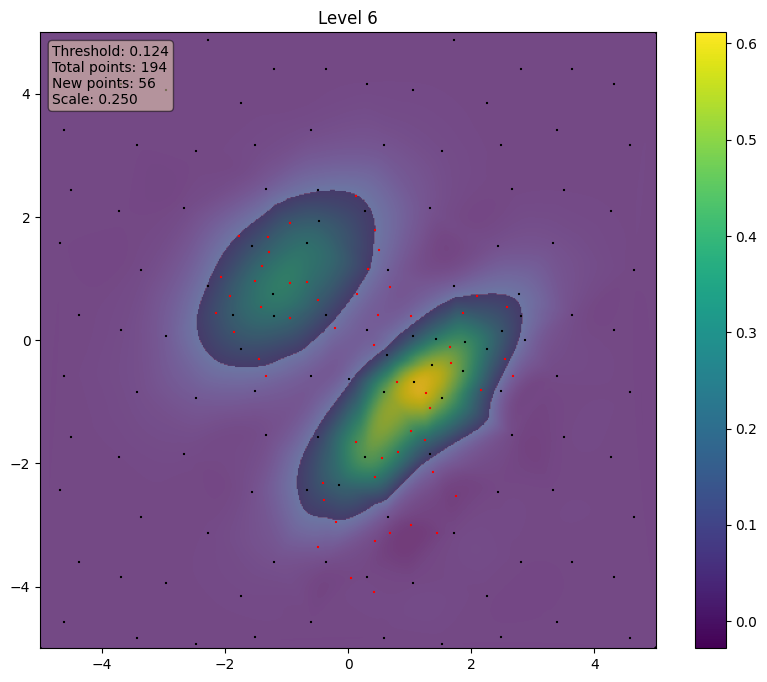

22
Level 7:
  Percentiles: work_obs=0.442, work=0.286, cal+delta=0.293
  Threshold: 0.286
  New points: 22


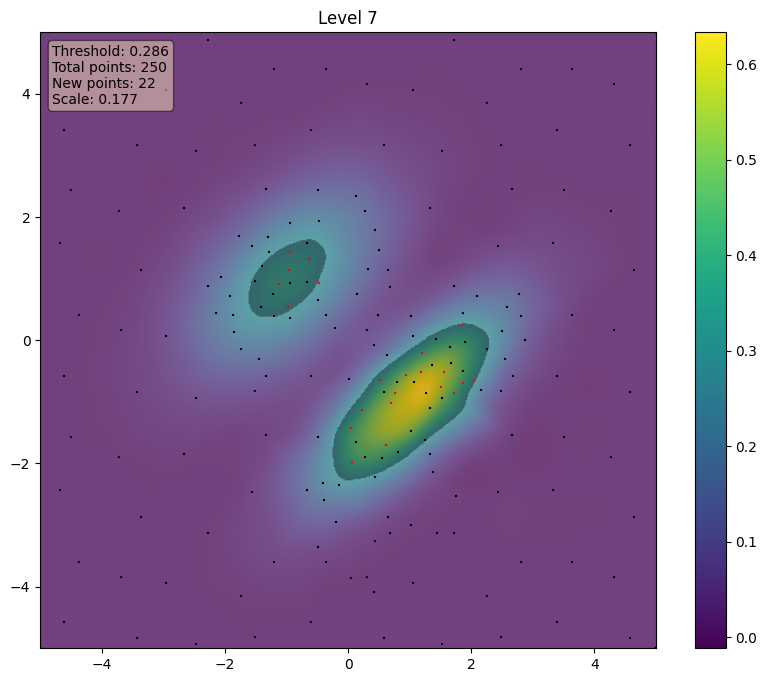

54
Level 8:
  Percentiles: work_obs=0.495, work=0.289, cal+delta=0.587
  Threshold: 0.289
  New points: 54


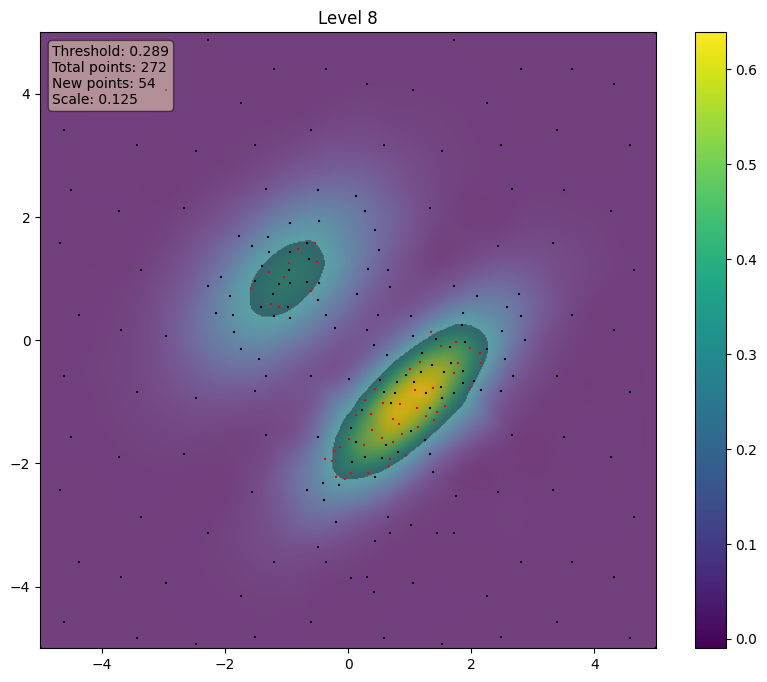

99
Level 9:
  Percentiles: work_obs=0.514, work=0.290, cal+delta=0.619
  Threshold: 0.290
  New points: 99


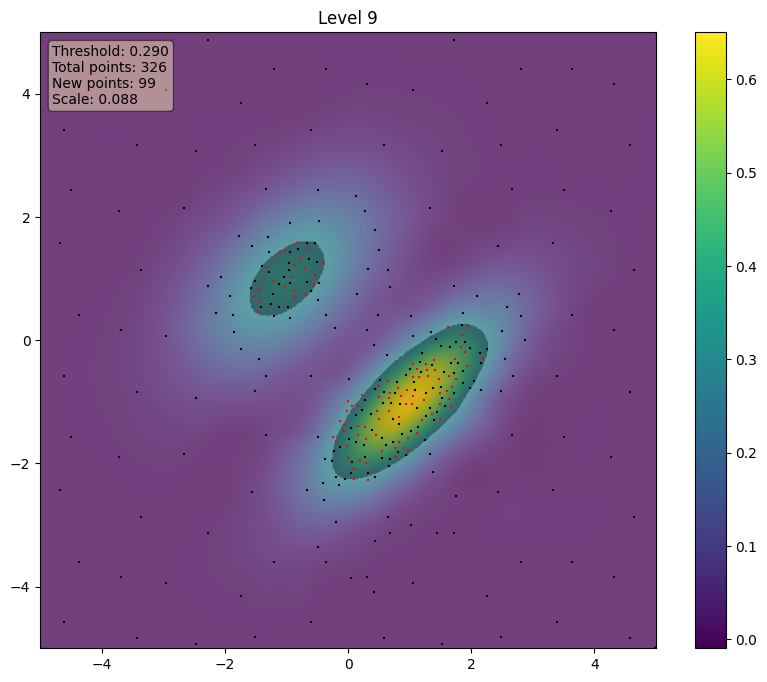

0
Level 10:
  Percentiles: work_obs=0.566, work=0.284, cal+delta=0.785
  Threshold: 0.284
  New points: 0


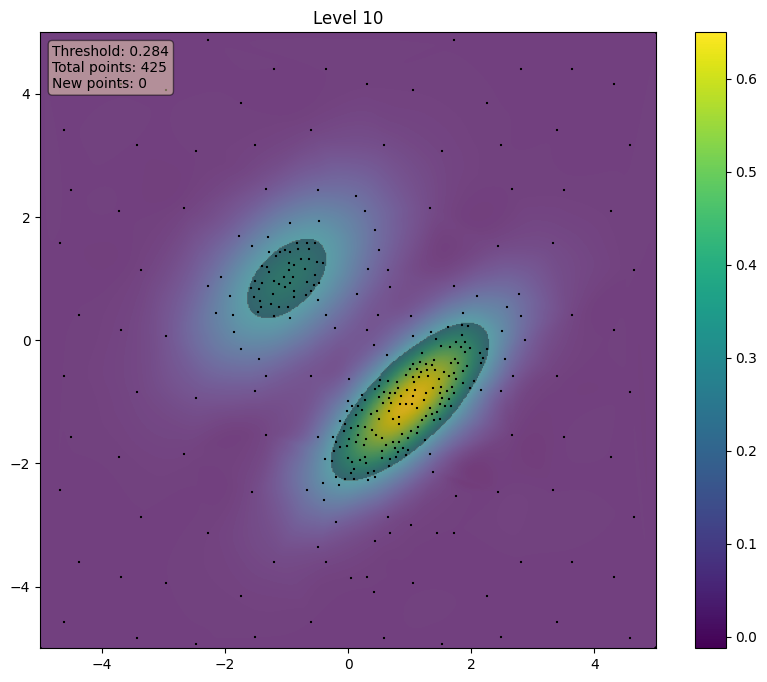

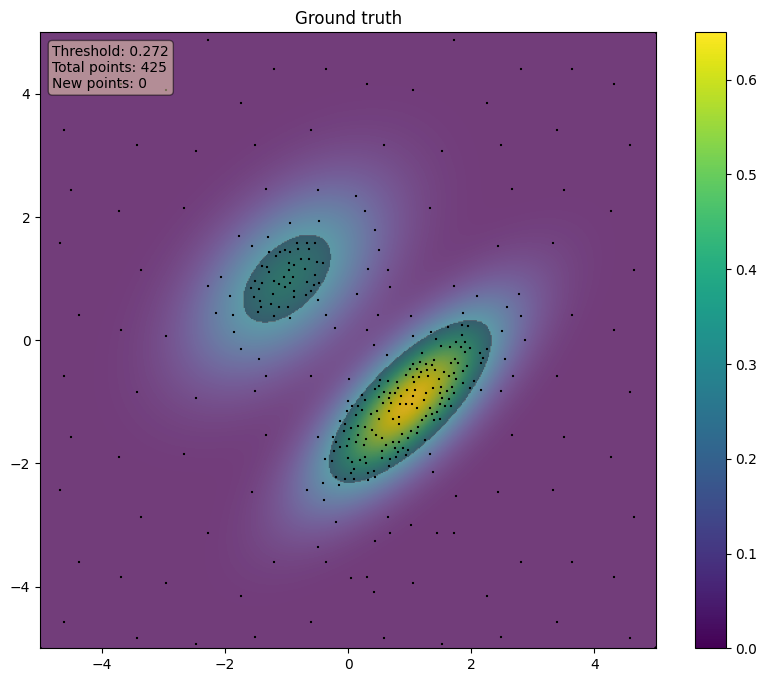

In [40]:
corners = np.array([[lower,lower],[lower,upper], [upper,lower], [upper,upper]])
clevels = np.array([0,0,0,0])

xy = np.concatenate([corners,xy])
levels = np.concatenate([clevels, levels])

selector = PointSelector(
        xy=xy,
        levels=levels,
        scales=scales,
        f_function=f,
        grid_x=grid_x,
        grid_y=grid_y,
        f_gt=f_gt,
        tau=95.0,
        sign=1,
        eps=0.00,
        start_level=3,
        set_aside=0.5,
        lower=lower,
        upper=upper,
        border_bias=0.50,
        radius_scale=3.0, n_splits_quantile=10, border=10
    )
    
# Run the algorithm
selected = selector.run(max_level=11)  # Just run for a few levels as an example
